<a href="https://colab.research.google.com/github/aminamh-29/automated-review-rating-system/blob/main/Electronics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.IMPORTING LIBRARIES

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2.LOAD THE DATASET

In [ ]:
import pandas as pd

df = pd.read_csv('Electronics.csv')
df.head()


,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,41409413,R2MTG1GCZLR2DK,B00428R89M,112201306,yoomall 5M Antenna WIFI RP-SMA Female to Male ...,Electronics,5,0,0,N,Y,Five Stars,As described.,2015-08-31
1,US,49668221,R2HBOEM8LE9928,B000068O48,734576678,"Hosa GPM-103 3.5mm TRS to 1/4"" TRS Adaptor",Electronics,5,0,0,N,Y,It works as advertising.,It works as advertising.,2015-08-31
2,US,12338275,R1P4RW1R9FDPEE,B000GGKOG8,614448099,Channel Master Titan 2 Antenna Preamplifier,Electronics,5,1,1,N,Y,Five Stars,Works pissa,2015-08-31
3,US,38487968,R1EBPM82ENI67M,B000NU4OTA,72265257,LIMTECH Wall charger + USB Hotsync & Charging ...,Electronics,1,0,0,N,Y,One Star,Did not work at all.,2015-08-31
4,US,23732619,R372S58V6D11AT,B00JOQIO6S,308169188,Skullcandy Air Raid Portable Bluetooth Speaker,Electronics,5,1,1,N,Y,Overall pleased with the item,Works well. Bass is somewhat lacking but is pr...,2015-08-31


In [ ]:
df.shape

(3093869, 15)

In [ ]:
df = df.rename(columns={
    "review_body": "review_text",
    "star_rating": "rating",
    "product_title": "product_name"
})


In [ ]:
df.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_name,product_category,rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_text,review_date
0,US,41409413,R2MTG1GCZLR2DK,B00428R89M,112201306,yoomall 5M Antenna WIFI RP-SMA Female to Male ...,Electronics,5,0,0,N,Y,Five Stars,As described.,2015-08-31
1,US,49668221,R2HBOEM8LE9928,B000068O48,734576678,"Hosa GPM-103 3.5mm TRS to 1/4"" TRS Adaptor",Electronics,5,0,0,N,Y,It works as advertising.,It works as advertising.,2015-08-31
2,US,12338275,R1P4RW1R9FDPEE,B000GGKOG8,614448099,Channel Master Titan 2 Antenna Preamplifier,Electronics,5,1,1,N,Y,Five Stars,Works pissa,2015-08-31
3,US,38487968,R1EBPM82ENI67M,B000NU4OTA,72265257,LIMTECH Wall charger + USB Hotsync & Charging ...,Electronics,1,0,0,N,Y,One Star,Did not work at all.,2015-08-31
4,US,23732619,R372S58V6D11AT,B00JOQIO6S,308169188,Skullcandy Air Raid Portable Bluetooth Speaker,Electronics,5,1,1,N,Y,Overall pleased with the item,Works well. Bass is somewhat lacking but is pr...,2015-08-31


In [ ]:
df['rating'].value_counts().sort_index()

,count
rating,
1,358120
2,179180
3,238587
4,536821
5,1781161


4.REMOVING UNWANTED COLUMNS

In [ ]:
df = df[["review_text", "rating","review_date","product_name"]]
df.head()

,review_text,rating,review_date,product_name
0,As described.,5,2015-08-31,yoomall 5M Antenna WIFI RP-SMA Female to Male ...
1,It works as advertising.,5,2015-08-31,"Hosa GPM-103 3.5mm TRS to 1/4"" TRS Adaptor"
2,Works pissa,5,2015-08-31,Channel Master Titan 2 Antenna Preamplifier
3,Did not work at all.,1,2015-08-31,LIMTECH Wall charger + USB Hotsync & Charging ...
4,Works well. Bass is somewhat lacking but is pr...,5,2015-08-31,Skullcandy Air Raid Portable Bluetooth Speaker


5.CREATING NEW DATASET

In [ ]:

TARGET_SIZE = 600000

ratio = df["rating"].value_counts(normalize=True)



In [ ]:

df_a = pd.concat([
    df[df["rating"] == r].sample(int(TARGET_SIZE * ratio[r]), random_state=42)
    for r in ratio.index
])


df_a = df_a.sample(frac=1, random_state=42).reset_index(drop=True)


print("Total reviews:", len(df_a))
df_a["rating"].value_counts().sort_index()
df_a.to_csv("Electronics_6Lakh.csv", index=False)


Total reviews: 599996


In [ ]:
original_ratio = df["rating"].value_counts(normalize=True).sort_index()
original_ratio


,proportion
rating,
1,0.115752
2,0.057915
3,0.077116
4,0.173511
5,0.575707


In [ ]:
new_ratio = df_a["rating"].value_counts(normalize=True).sort_index()
new_ratio


,proportion
rating,
1,0.115751
2,0.057914
3,0.077116
4,0.173511
5,0.575709


In [ ]:
len(df_a)


599996

In [ ]:
df_a['rating'].value_counts().sort_index()

,count
rating,
1,69450
2,34748
3,46269
4,104106
5,345423


In [ ]:
df=pd.read_csv('Electronics_6Lakh.csv')
print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (599996, 4)


,review_text,rating,review_date,product_name
0,works as advertised. great multi-functional t...,5,2015-07-17,Eton Scorpion Multifunction Radio
1,The iPod came with the title Kevin Lees iPod ?...,5,2007-08-04,Apple iPod nano 4 GB Silver
2,I bought both an Oppo HDMI switcher (this revi...,5,2007-12-24,OPPO HM-31 Advanced HDMI 1.3 and 1080p Switch ...
3,Very sturdy replacement stand. Makes the TV st...,5,2015-04-01,Atlantic Table Top TV Stand
4,I bought a sansa clip for myself in april 2008...,1,2008-12-30,SanDisk Sansa Clip 2 GB MP3 Player


5.REMOVING DUPLICATES

In [ ]:
df = df.drop_duplicates(subset=['review_text', 'rating'], keep='first')
df.head()


,review_text,rating,review_date,product_name
0,works as advertised. great multi-functional t...,5,2015-07-17,Eton Scorpion Multifunction Radio
1,The iPod came with the title Kevin Lees iPod ?...,5,2007-08-04,Apple iPod nano 4 GB Silver
2,I bought both an Oppo HDMI switcher (this revi...,5,2007-12-24,OPPO HM-31 Advanced HDMI 1.3 and 1080p Switch ...
3,Very sturdy replacement stand. Makes the TV st...,5,2015-04-01,Atlantic Table Top TV Stand
4,I bought a sansa clip for myself in april 2008...,1,2008-12-30,SanDisk Sansa Clip 2 GB MP3 Player


6.CHECKING MISSING VALUES

In [ ]:
df[['review_text', 'rating','review_date']].isnull().sum()


,0
review_text,4
rating,0
review_date,0


In [ ]:
df[['product_name',]].isnull().sum()


,0
product_name,1


7.FILLING THE MISSING VALUES

In [ ]:
df['review_text'] = df['review_text'].fillna(df['review_text'].mode()[0])

In [ ]:
df['product_name'] = df['product_name'].fillna(df['product_name'].mode()[0])

8.HANDLING THE MISSING VALUES

In [ ]:
df[['review_text', 'rating','review_date','product_name']].isnull().sum()


,0
review_text,0
rating,0
review_date,0
product_name,0


In [ ]:
df['rating'].value_counts().sort_index()

,count
rating,
1,68600
2,34666
3,45684
4,100796
5,323006


9.EXACT DUPLICATES REMOVED

In [ ]:
df = df.drop_duplicates(subset=['review_text', 'rating'])
print("Exact duplicates removed:", df.shape)

Exact duplicates removed: (572748, 4)


10.CONFLICTING REVIEWS REMOVED

In [ ]:
df = df[df.groupby('review_text')['rating'].transform('nunique') == 1]
print("Conflicting reviews removed")
print(df.shape)

Conflicting reviews removed
(569199, 4)


11.TOTAL REVIEW COUNT

In [ ]:
total_reviews = len(df)
print("Total Reviews Count:", total_reviews)


Total Reviews Count: 569199


12.RATING DISTRIBUTION

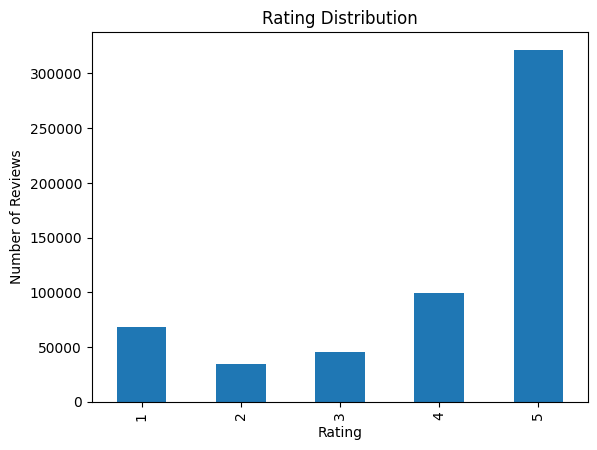

In [ ]:
import matplotlib.pyplot as plt

rating_counts = df['rating'].value_counts().sort_index()

plt.figure()
rating_counts.plot(kind='bar')
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Rating Distribution")
plt.show()


13.AVERAGE REVIEW LENGTH

rating
1    68.383797
2    88.384319
3    90.048265
4    89.598490
5    64.013772
Name: review_length_words, dtype: float64


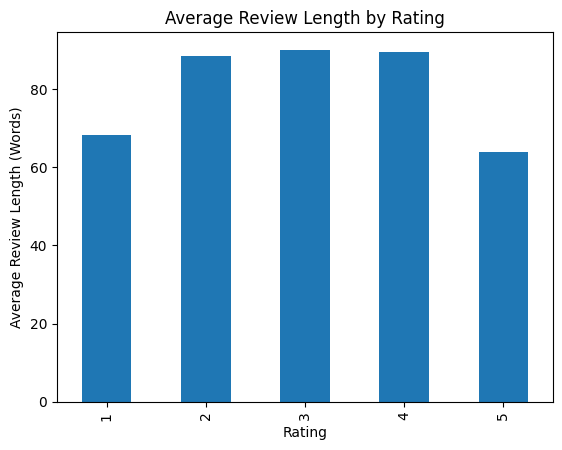

In [ ]:
df["review_length_words"] = df["review_text"].astype(str).str.split().str.len()

avg_len_by_rating = df.groupby("rating")["review_length_words"].mean()
print(avg_len_by_rating)

plt.figure()
avg_len_by_rating.plot(kind="bar")
plt.xlabel("Rating")
plt.ylabel("Average Review Length (Words)")
plt.title("Average Review Length by Rating")
plt.show()


14.TEMPORAL TRENDS

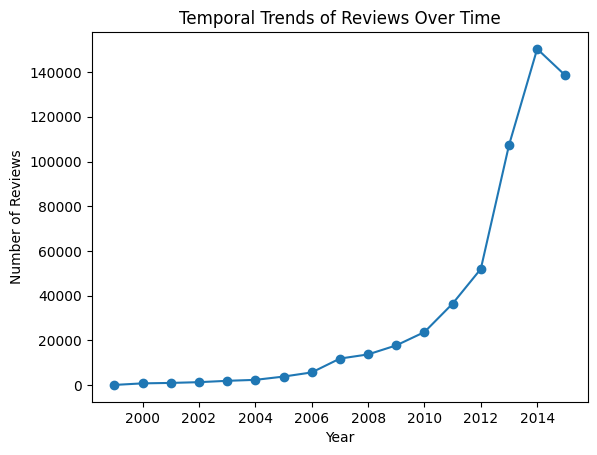

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")
df["year"] = df["review_date"].dt.year
reviews_per_year = df["year"].value_counts().sort_index()
plt.figure()
plt.plot(reviews_per_year.index, reviews_per_year.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.title("Temporal Trends of Reviews Over Time")
plt.show()


15.LOWERCASING ALL

In [ ]:



df["review_text"] = df["review_text"].astype(str).str.lower()
df.head()

,review_text,rating,review_date,product_name,review_length_words,year
0,works as advertised. great multi-functional t...,5,2015-07-17,Eton Scorpion Multifunction Radio,54,2015
1,the ipod came with the title kevin lees ipod ?...,5,2007-08-04,Apple iPod nano 4 GB Silver,21,2007
2,i bought both an oppo hdmi switcher (this revi...,5,2007-12-24,OPPO HM-31 Advanced HDMI 1.3 and 1080p Switch ...,547,2007
3,very sturdy replacement stand. makes the tv st...,5,2015-04-01,Atlantic Table Top TV Stand,18,2015
4,i bought a sansa clip for myself in april 2008...,1,2008-12-30,SanDisk Sansa Clip 2 GB MP3 Player,101,2008


16.REMOVING URLS ,HTML TAGS ETC..

In [ ]:
import re

def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'<.*?>', '', text)            # remove HTML tags
    text = re.sub(r'[^a-z\s]', '', text)         # remove emojis, punctuation, special chars
    return text
df['clean_text'] = df['review_text'].apply(clean_text)
df.head()

,review_text,rating,review_date,product_name,review_length_words,year,clean_text
0,works as advertised. great multi-functional t...,5,2015-07-17,Eton Scorpion Multifunction Radio,54,2015,works as advertised great multifunctional too...
1,the ipod came with the title kevin lees ipod ?...,5,2007-08-04,Apple iPod nano 4 GB Silver,21,2007,the ipod came with the title kevin lees ipod ...
2,i bought both an oppo hdmi switcher (this revi...,5,2007-12-24,OPPO HM-31 Advanced HDMI 1.3 and 1080p Switch ...,547,2007,i bought both an oppo hdmi switcher this revie...
3,very sturdy replacement stand. makes the tv st...,5,2015-04-01,Atlantic Table Top TV Stand,18,2015,very sturdy replacement stand makes the tv sta...
4,i bought a sansa clip for myself in april 2008...,1,2008-12-30,SanDisk Sansa Clip 2 GB MP3 Player,101,2008,i bought a sansa clip for myself in april and...


17.STOP WORDS REMOVAL

In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

STOPWORDS = ENGLISH_STOP_WORDS

all_text = " ".join(df["clean_text"])

words = all_text.split()

unique_stops = {w for w in words if w in STOPWORDS}
df.tail()



,review_text,rating,review_date,product_name,review_length_words,year,clean_text
599991,"such a great solution to keep chords tidy, out...",5,2015-02-27,"Cable Management Systems, Two Boxes : 15.6 and...",18,2015,such a great solution to keep chords tidy out ...
599992,i don't feel that i have much to add after so ...,5,2014-11-13,Sennheiser Headphones,52,2014,i dont feel that i have much to add after so m...
599993,this plate is very easy to install (no solderi...,4,2008-08-29,HiFi Works 30021 HFWWP-1 Single Speaker Wallpl...,25,2008,this plate is very easy to install no solderin...
599994,"this is a surprisingly strong little antenna, ...",5,2014-09-04,TRAM 1600-HC 35 - Inch VHF Marine Antenna,53,2014,this is a surprisingly strong little antenna j...
599995,great for behind the cabinet installations whe...,5,2015-06-26,APC Wall Tap Surgearrest Essential P6WU2,20,2015,great for behind the cabinet installations whe...


In [ ]:
df.shape

(569199, 7)

18.LEMMETIAZATION

In [ ]:
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

df['lemmatize_Review'] = df['clean_text'].apply(lemmatize_text)
df.head()


,review_text,rating,review_date,product_name,review_length_words,year,clean_text,lemmatize_Review
0,works as advertised. great multi-functional t...,5,2015-07-17,Eton Scorpion Multifunction Radio,54,2015,works as advertised great multifunctional too...,work a advertised great multifunctional tool i...
1,the ipod came with the title kevin lees ipod ?...,5,2007-08-04,Apple iPod nano 4 GB Silver,21,2007,the ipod came with the title kevin lees ipod ...,the ipod came with the title kevin lee ipod is...
2,i bought both an oppo hdmi switcher (this revi...,5,2007-12-24,OPPO HM-31 Advanced HDMI 1.3 and 1080p Switch ...,547,2007,i bought both an oppo hdmi switcher this revie...,i bought both an oppo hdmi switcher this revie...
3,very sturdy replacement stand. makes the tv st...,5,2015-04-01,Atlantic Table Top TV Stand,18,2015,very sturdy replacement stand makes the tv sta...,very sturdy replacement stand make the tv stan...
4,i bought a sansa clip for myself in april 2008...,1,2008-12-30,SanDisk Sansa Clip 2 GB MP3 Player,101,2008,i bought a sansa clip for myself in april and...,i bought a sansa clip for myself in april and ...


In [ ]:
# Select only the required columns
cleaned_dataset_electronics = df[['lemmatize_Review', 'rating']]

# Save to CSV
# Save to data folder
cleaned_dataset_electronics.to_csv("Electronics_6Lakh.csv", index=False)


print("Dataset saved successfully in data/ folder")


Dataset saved successfully in data/ folder


19.FILTERING WORDS

In [ ]:
# filtering words
def filter_review(text, min_words=3, max_words=350):
    words = text.split()

    if len(words) < min_words:
        return False
    if len(words) > max_words:
        return False

    return True

20.WORD FREQUENCY DISTRIBUTION

In [ ]:
from collections import Counter
word_freq_by_rating = {}

for r in sorted(df["rating"].unique()):
    words = " ".join(df[df["rating"] == r]["clean_text"]).split()
    word_freq_by_rating[r] = Counter(words)
for r, counter in word_freq_by_rating.items():
    print(f"\nTop 10 words for Rating {r}:")
    print(counter.most_common(5))



Top 10 words for Rating 1:
[('the', 237407), ('i', 151467), ('to', 126675), ('and', 116161), ('it', 115416)]

Top 10 words for Rating 2:
[('the', 168486), ('i', 93033), ('to', 84347), ('and', 72579), ('a', 68472)]

Top 10 words for Rating 3:
[('the', 228648), ('i', 117008), ('to', 112735), ('a', 95037), ('and', 92969)]

Top 10 words for Rating 4:
[('the', 483804), ('i', 248001), ('to', 244304), ('a', 222861), ('and', 222800)]

Top 10 words for Rating 5:
[('the', 998127), ('i', 621850), ('and', 607157), ('to', 543883), ('a', 489284)]


21. word clouds for ratings 1-star and 5-star


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
star_1 = " ".join(df[df["rating"] == 1]["clean_text"])
star_5 = " ".join(df[df["rating"] == 5]["clean_text"])
wc_1 = WordCloud(background_color="white").generate(star_1)
wc_5 = WordCloud(background_color="white").generate(star_5)



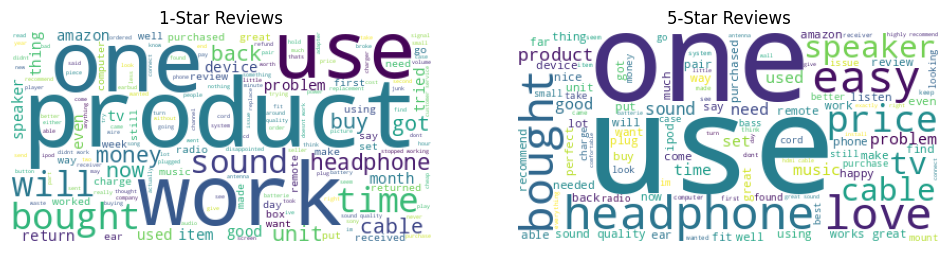

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(wc_1)
plt.axis("off")
plt.title("1-Star Reviews")

plt.subplot(1, 2, 2)
plt.imshow(wc_5)
plt.axis("off")
plt.title("5-Star Reviews")

plt.show()


22.Top 20 keywords per rating

In [ ]:
from collections import Counter

for r in sorted(df["rating"].dropna().unique()):
    reviews = df[df["rating"] == r]["lemmatize_Review"]
    all_words = " ".join(reviews).split()
    word_counts = Counter(all_words)
    print(f"\nTop 20 keywords for Rating {r}:")
    print(word_counts.most_common(20))



Top 20 keywords for Rating 1:
[('the', 237407), ('i', 151467), ('it', 128104), ('a', 127109), ('to', 126675), ('and', 116161), ('this', 65505), ('of', 65346), ('not', 58677), ('is', 57738), ('for', 53741), ('in', 45548), ('my', 45471), ('that', 44995), ('wa', 43727), ('on', 41108), ('with', 37895), ('but', 33495), ('have', 32701), ('you', 32368)]

Top 20 keywords for Rating 2:
[('the', 168486), ('i', 93033), ('to', 84347), ('a', 84228), ('it', 76837), ('and', 72579), ('is', 43876), ('of', 42699), ('for', 37342), ('this', 34492), ('not', 31912), ('in', 31017), ('that', 30526), ('my', 29524), ('but', 27815), ('on', 26351), ('with', 26052), ('wa', 24924), ('you', 23131), ('have', 22210)]

Top 20 keywords for Rating 3:
[('the', 228648), ('a', 119155), ('i', 117008), ('to', 112735), ('it', 104866), ('and', 92969), ('is', 67076), ('of', 55169), ('for', 54875), ('that', 43276), ('but', 43218), ('this', 41601), ('in', 41101), ('not', 39628), ('my', 39145), ('with', 35797), ('on', 34901), ('yo

23.Sentiment-heavy words by rating

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
def sentiment_words(rating):
    reviews = df[df["rating"] == rating]["review_text"].astype(str)
    vectorizer = CountVectorizer(stop_words="english", max_features=10)
    vectorizer.fit(reviews)
    return vectorizer.get_feature_names_out()


In [ ]:
print("1-Star (Negative):", sentiment_words(1))
print("2-Star:", sentiment_words(2))
print("3-Star (Neutral):", sentiment_words(3))
print("4-Star:", sentiment_words(4))
print("5-Star (Positive):", sentiment_words(5))


1-Star (Negative): ['bought' 'br' 'buy' 'did' 'just' 'product' 'sound' 'time' 'use' 'work']
2-Star: ['br' 'good' 'headphones' 'just' 'like' 'product' 'quality' 'sound' 'use'
 'work']
3-Star (Neutral): ['br' 'good' 'great' 'headphones' 'just' 'like' 'quality' 'sound' 'use'
 'work']
4-Star: ['br' 'good' 'great' 'headphones' 'just' 'like' 'price' 'quality' 'sound'
 'use']
5-Star (Positive): ['br' 'good' 'great' 'just' 'like' 'price' 'quality' 'sound' 'use' 'works']


In [ ]:
df[["product_name", "rating"]].head()


,product_name,rating
0,Eton Scorpion Multifunction Radio,5
1,Apple iPod nano 4 GB Silver,5
2,OPPO HM-31 Advanced HDMI 1.3 and 1080p Switch ...,5
3,Atlantic Table Top TV Stand,5
4,SanDisk Sansa Clip 2 GB MP3 Player,1


24.PRODUCT WISE RATING DISTRIBUTION

1.PRODUCTS WITH 5 STAR REVIEWS FREQUENTLY

In [ ]:
top_5 = (
    df[df["rating"] == 5]
    .groupby("product_name")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="5 STAR REVIEWS COUNT")
)

top_5


,product_name,5 STAR REVIEWS COUNT
0,Panasonic ErgoFit In-Ear Earbud Headphone,3077
1,Mediabridge ULTRA Series HDMI Cable (3 Foot) -...,2443
2,AmazonBasics High-Speed HDMI Cable - 6.5 Feet ...,2168
3,AmazonBasics High Speed HDMI Cable,1567
4,High Speed HDMI Cable (1.5 Feet) With Ethernet...,1554
5,CABTE High speed HDMI 1.4 HDMI cable 10ft 1080...,1413
6,"VideoSecu ML531BE TV Wall Mount for most 22""-5...",1386
7,HDMI-High-Speed,1289
8,"Cheetah APTMM2B TV Wall Mount for 20-75"" TVs u...",1149
9,Sanyo NEW 1500 eneloop AA Ni-MH Pre-Charged Re...,1100


2.PRODUCTS WITH 1 STAR REVIEWS

In [ ]:
top_1 = (
    df[df["rating"] == 1]
    .groupby("product_name")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="1 STAR REVIEWS COUNT")
)

top_1


,product_name,1 STAR REVIEWS COUNT
0,Clip Plus 4 GB MP3 Player (Black),401
1,Panasonic ErgoFit In-Ear Earbud Headphone,206
2,MEElectronics Sport-Fi M6 Noise Isolating In-E...,171
3,JLab JBuds Hi-Fi Noise-Reducing Ear Buds (Purple),169
4,Mediasonic Homeworx HW110AN Super Thin Indoor ...,167
5,Sennheiser On-Ear 926MHz Wireless RF Headphone...,163
6,High Speed HDMI Cable (1.5 Feet) With Ethernet...,153
7,PORTTA Auto-Switching 3-Port HDMI2,153
8,BCAPTURE DC60 - USB 2.0 Video Capture Adapter ...,145
9,SDMX22-004G-PAR,135


3.PRODUCT DIVERSITY ACROSS RATINGS


In [ ]:
rating_diversity = (
    df.groupby("product_name")["rating"]
    .nunique()
    .reset_index(name="rating_diversity")
)
mixed_rating_diversity = rating_diversity[
    (rating_diversity["rating_diversity"] >= 2) &
    (rating_diversity["rating_diversity"] <= 5)
]

mixed_rating_diversity.head(10)


,product_name,rating_diversity
5,"""Black Buds"" HDSS® Earbuds",2
13,"""MUSIC MUFF"" THE FLEECE STEREO HEADPHONE EAR M...",2
16,"""Philco"" Universal Turntable Replacement Stylu...",3
21,#1 BEST SELLING Waterproof Bluetooth Speaker w...,4
22,#1 Best Auxiliary Audio Cable With Top-Notch S...,2
30,#1 Falcon 80-6 Meter Off Center Fed Dipole Ama...,2
32,#1 Falcon Off Center Fed 40-6 Meter Dipole Ama...,2
33,#1 Rated Alarm Clock Fm Radio with Dual Alarm ...,4
34,#1 Universal TV Box Mount Holder Mounting Brac...,4
39,$20 International Rechargeable Calling Card No...,3


In [ ]:
rating_diversity = (
    df.groupby("product_name")["rating"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="rating_diversity")
)

rating_diversity.head(10)


In [ ]:
rating_diversity.sort_values("rating_diversity").head(10)


In [ ]:
rating_diversity["rating_diversity"].value_counts()


25.TOP 10 PRODUCT REVIEWS COUNT

In [ ]:
top_10 = (df["product_name"].value_counts().head(10).reset_index())
top_10.columns = ["product_name", "review_count"]
top_10


26.AVERAGE REVIEW LENGTH

1.CHAR/WORDS PER RATING

In [ ]:
from textblob import TextBlob

df["char_len"] = df["review_text"].astype(str).str.len()
df["word_len"] = df["review_text"].astype(str).str.split().str.len()

df.groupby("rating")[["char_len", "word_len"]].mean().reset_index()


27.REVIEW POLARITY RATING

In [ ]:
from textblob import TextBlob

# Calculate polarity for each review
df["polarity"] = df["review_text"].astype(str).apply(
    lambda x: TextBlob(x).sentiment.polarity
)

# Display rating + review text + polarity
df[["rating", "review_text", "polarity"]].head(10)


28.SUBJECTIVITY SCORE

In [ ]:
df["subjectivity"] = df["review_text"].astype(str).apply(lambda x: TextBlob(x).sentiment.subjectivity)
df[["rating", "review_text", "subjectivity"]].head(10)



31.SENTIMENT INTENSITY

In [ ]:
df["polarity"] = df["review_text"].astype(str).apply(
    lambda x: TextBlob(x).sentiment.polarity
)


KeyboardInterrupt: 

In [ ]:
df["sentiment_intensity"] = df["polarity"].abs()


In [ ]:
df[["rating", "review_text", "polarity", "sentiment_intensity"]].head(10)


NLP INSIGHTS

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')   # required for Python 3.12


In [ ]:
from textblob import TextBlob
import pandas as pd

# Aspect keywords
aspects = [
    "battery", "battery life", "charging", "charger",
    "screen", "display", "touch", "resolution",
    "sound", "speaker", "audio", "volume",
    "camera", "photo", "video",
    "price", "cost", "value",
    "performance", "speed", "processor",
    "memory", "storage", "ram",
    "design", "build", "quality",
    "cable", "usb", "hdmi", "adapter"
]

def aspect_sentiment(text):
    result = {}
    text = str(text).lower()       # safety conversion
    blob = TextBlob(text)

    for sentence in blob.sentences:
        sent_text = str(sentence)
        for aspect in aspects:
            if aspect in sent_text:
                # store sentiment polarity
                result[aspect] = round(sentence.sentiment.polarity, 3)

    return result

# Apply to dataframe
df["aspect_sentiment"] = df["review_text"].apply(aspect_sentiment)

# View result
df[["rating", "review_text", "aspect_sentiment"]].head(10)


32.ASPECT SENTIMENT

NAMED ENITITY

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser", "lemmatizer"])

sample_df = df.sample(3000, random_state=42)

def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

sample_df["entities"] = sample_df["review_text"].astype(str).apply(extract_entities)

sample_df[["rating", "entities"]].head()


In [ ]:
df["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.show()


HEATMAP RATING VS PRODCUT NAME

In [ ]:
df["product_short"] = df["product_name"].str[:20]

top_products = df["product_name"].value_counts().head(10).index

pivot = pd.pivot_table(
    df[df["product_name"].isin(top_products)],
    values="review_text",
    index="product_short",
    columns="rating",
    aggfunc="count"
)

sns.heatmap(pivot.fillna(0), annot=True, fmt="d")
plt.show()


TRAIN-TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X = df['lemmatize_Review']
y = df['rating']

# Train–test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=y
)
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nClass distribution in training set:")
print(y_train.value_counts().sort_index())
print("\nClass distribution in testing set:")
print(y_test.value_counts().sort_index())


Training set size: 455359
Testing set size: 113840

Class distribution in training set:
rating
1     54735
2     27579
3     36200
4     79562
5    257283
Name: count, dtype: int64

Class distribution in testing set:
rating
1    13684
2     6895
3     9050
4    19890
5    64321
Name: count, dtype: int64


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=5000)

# Fit TF-IDF only on TRAIN data (to avoid data leakage)
X_train_vec = vectorizer.fit_transform(X_train)

# Transform TEST data using the same learned vocabulary
X_test_vec = vectorizer.transform(X_test)

print("Vectorization completed successfully!")
print("Training data shape:", X_train_vec.shape)
print("Testing data shape:", X_test_vec.shape)


Vectorization completed successfully!
Training data shape: (455359, 5000)
Testing data shape: (113840, 5000)


In [ ]:
from sklearn.linear_model import LogisticRegression
logit = LogisticRegression(solver='newton-cg')
logit.fit(X_train_vec,y_train)
y_pred_train = logit.predict(X_train_vec)
y_pred_test = logit.predict(X_test_vec)
print("logistic regression trained")

logistic regression trained


In [ ]:
 from sklearn.metrics import accuracy_score
print("train:",accuracy_score(y_train,y_pred_train))
print("test:",accuracy_score(y_test,y_pred_test))

train: 0.7016573736326722
test: 0.6889318341531975


In [ ]:
from sklearn.metrics import classification_report
print("train:",classification_report(y_train,y_pred_train))
print("test:",classification_report(y_test,y_pred_test))

train:               precision    recall  f1-score   support

           1       0.66      0.77      0.71     54735
           2       0.44      0.17      0.25     27579
           3       0.44      0.26      0.33     36200
           4       0.51      0.29      0.37     79562
           5       0.77      0.93      0.84    257283

    accuracy                           0.70    455359
   macro avg       0.56      0.49      0.50    455359
weighted avg       0.66      0.70      0.67    455359

test:               precision    recall  f1-score   support

           1       0.64      0.75      0.69     13684
           2       0.37      0.15      0.21      6895
           3       0.38      0.23      0.29      9050
           4       0.48      0.27      0.35     19890
           5       0.76      0.93      0.84     64321

    accuracy                           0.69    113840
   macro avg       0.53      0.47      0.48    113840
weighted avg       0.64      0.69      0.65    113840



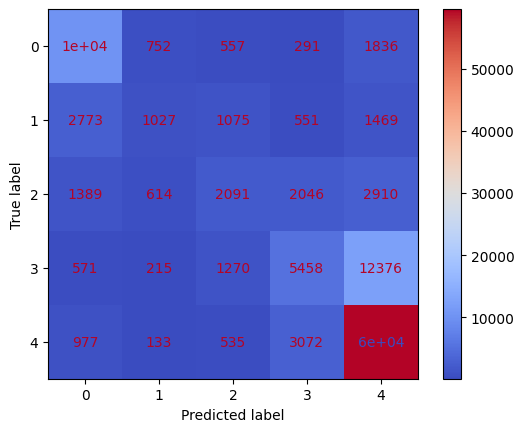

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.coolwarm)

plt.show()


In [ ]:
#Train Model C-Multinomial Naive bayes
from sklearn.naive_bayes import MultinomialNB
model_nb = MultinomialNB()
model_nb.fit(X_train_vec, y_train)
y_pred_train_2= model_nb.predict(X_train_vec)
y_pred_test_2= model_nb.predict(X_test_vec)
print("Multinomial Naive bayes Trained")


Multinomial Naive bayes Trained


In [ ]:
 from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

print("train:",accuracy_score(y_train,y_pred_train_2))
print("test:",accuracy_score(y_test,y_pred_test_2))

train: 0.6274368135910348
test: 0.6263352073085031


In [ ]:
print("train:",classification_report(y_train,y_pred_train_2))
print("test:",classification_report(y_test,y_pred_test_2))

train:               precision    recall  f1-score   support

           1       0.70      0.47      0.57     54735
           2       0.48      0.01      0.02     27579
           3       0.41      0.01      0.03     36200
           4       0.42      0.06      0.11     79562
           5       0.63      0.99      0.77    257283

    accuracy                           0.63    455359
   macro avg       0.53      0.31      0.30    455359
weighted avg       0.57      0.63      0.52    455359

test:               precision    recall  f1-score   support

           1       0.71      0.47      0.57     13684
           2       0.46      0.01      0.02      6895
           3       0.38      0.01      0.02      9050
           4       0.40      0.06      0.10     19890
           5       0.63      0.99      0.77     64321

    accuracy                           0.63    113840
   macro avg       0.52      0.31      0.30    113840
weighted avg       0.57      0.63      0.52    113840



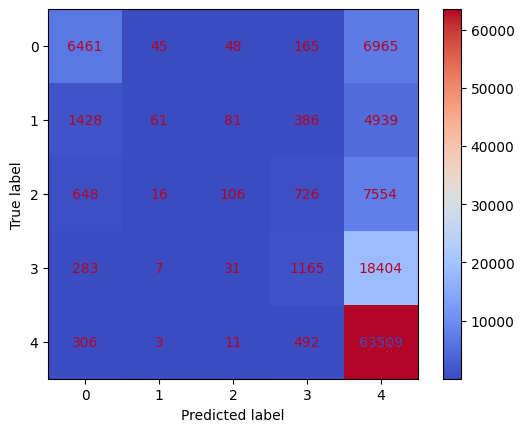

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
c_matrix=ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred_test_2))
c_matrix.plot(cmap = plt.cm.coolwarm)
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Labels: 1–5 → 0–4
y_train_dl = y_train - 1
y_test_dl  = y_test - 1

num_classes = len(y_train.unique())  # 5

# Tokenization
max_words = 30000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding="post")


In [ ]:


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding

embedding_dim = 128

model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=embedding_dim
    )
])

# Optional (only if you want summary immediately)
model.build(input_shape=(None, max_len))
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     3,840,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,840,000 (14.65 MB)

 Trainable params: 3,840,000 (14.65 MB)

 Non-trainable params: 0 (0.00 B)

GRU

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# labels already fixed: y_train_dl, y_test_dl (0–4)

model_gru = Sequential([
    Embedding(input_dim=max_words, output_dim=128),   # removed input_length
    Bidirectional(GRU(128)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_gru.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

model_gru.fit(
    X_train_pad,
    y_train_dl,
    epochs=40,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

y_pred_gru= np.argmax(model_gru.predict(X_test_pad), axis=1)

print(" GRU Accuracy:", accuracy_score(y_test_dl, y_pred_gru))
print(
    "\nClassification Report:\n",
    classification_report(y_test_dl, y_pred_gru, zero_division=0)
)
print("\nConfusion Matrix:\n", confusion_matrix(y_test_dl, y_pred_gru))


Epoch 1/40
3202/3202 ━━━━━━━━━━━━━━━━━━━━ 114s 32ms/step - accuracy: 0.6489 - loss: 0.9213 - val_accuracy: 0.7053 - val_loss: 0.7400
Epoch 2/40
3202/3202 ━━━━━━━━━━━━━━━━━━━━ 103s 32ms/step - accuracy: 0.7202 - loss: 0.7069 - val_accuracy: 0.7174 - val_loss: 0.7127
Epoch 3/40
3202/3202 ━━━━━━━━━━━━━━━━━━━━ 104s 33ms/step - accuracy: 0.7417 - loss: 0.6544 - val_accuracy: 0.7169 - val_loss: 0.7200
Epoch 4/40
3202/3202 ━━━━━━━━━━━━━━━━━━━━ 104s 32ms/step - accuracy: 0.7644 - loss: 0.6028 - val_accuracy: 0.7133 - val_loss: 0.7520
3558/3558 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step
 GRU Accuracy: 0.7181131412508784

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.84      0.73     13684
           1       0.39      0.17      0.24      6895
           2       0.42      0.32      0.36      9050
           3       0.53      0.31      0.39     19890
           4       0.81      0.93      0.86     64321

    accuracy                           

CNN

In [ ]:
# ===============================
# FULL CNN MODEL – ONE STEP
# ===============================

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 🔹 CNN Model
model_cnn = Sequential([
    Embedding(input_dim=max_words, output_dim=200, input_length=max_len),

    Conv1D(filters=256, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

# 🔹 Compile
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 🔹 Train
model_cnn.fit(
    X_train_pad,
    y_train_dl,
    epochs=40,                 # ✅ as required
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# 🔹 Predict
y_pred_cnn = np.argmax(model_cnn.predict(X_test_pad), axis=1)

# 🔹 Evaluation
print("\nCNN Accuracy:", accuracy_score(y_test_dl, y_pred_cnn))
print("\nClassification Report:\n", classification_report(y_test_dl, y_pred_cnn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_dl, y_pred_cnn))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/40
3202/3202 ━━━━━━━━━━━━━━━━━━━━ 88s 24ms/step - accuracy: 0.6580 - loss: 0.8961 - val_accuracy: 0.7097 - val_loss: 0.7329
Epoch 2/40
3202/3202 ━━━━━━━━━━━━━━━━━━━━ 95s 29ms/step - accuracy: 0.7209 - loss: 0.7023 - val_accuracy: 0.7150 - val_loss: 0.7319
Epoch 3/40
3202/3202 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - accuracy: 0.7520 - loss: 0.6205 - val_accuracy: 0.7111 - val_loss: 0.7511
Epoch 4/40
3202/3202 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - accuracy: 0.7874 - loss: 0.5320 - val_accuracy: 0.6969 - val_loss: 0.8522
Epoch 5/40
3202/3202 ━━━━━━━━━━━━━━━━━━━━ 53s 17ms/step - accuracy: 0.8226 - loss: 0.4468 - val_accuracy: 0.6955 - val_loss: 0.9525
3558/3558 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step

CNN Accuracy: 0.7115513000702741

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.79      0.72     13684
           1       0.37      0.19      0.25      6895
           2       0.38      0.37      0.37      9050
           3       0

**BILSTM**

In [ ]:


import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 🔹 Build BiLSTM Model
model_bilstm = Sequential([
    Embedding(input_dim=max_words, output_dim=200),  # input_length removed (deprecated)

    Bidirectional(LSTM(64)),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

# 🔹 Compile Model
model_bilstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 🔹 Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 🔹 Train Model
model_bilstm.fit(
    X_train_pad,
    y_train_dl,
    epochs=40,                 # ✅ required
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# 🔹 Predict on Test Data
y_pred_bilstm = np.argmax(model_bilstm.predict(X_test_pad), axis=1)

# 🔹 Evaluation
print("\nBiLSTM Accuracy:", accuracy_score(y_test_dl, y_pred_bilstm))
print("\nClassification Report:\n", classification_report(y_test_dl, y_pred_bilstm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_dl, y_pred_bilstm))


Epoch 1/40
3202/3202 ━━━━━━━━━━━━━━━━━━━━ 102s 31ms/step - accuracy: 0.6524 - loss: 0.9132 - val_accuracy: 0.6985 - val_loss: 0.7704
Epoch 2/40
3202/3202 ━━━━━━━━━━━━━━━━━━━━ 98s 30ms/step - accuracy: 0.7103 - loss: 0.7347 - val_accuracy: 0.7076 - val_loss: 0.7461
Epoch 3/40
3202/3202 ━━━━━━━━━━━━━━━━━━━━ 99s 31ms/step - accuracy: 0.7335 - loss: 0.6761 - val_accuracy: 0.7103 - val_loss: 0.7301
Epoch 4/40
3202/3202 ━━━━━━━━━━━━━━━━━━━━ 98s 31ms/step - accuracy: 0.7543 - loss: 0.6275 - val_accuracy: 0.7046 - val_loss: 0.7553
Epoch 5/40
3202/3202 ━━━━━━━━━━━━━━━━━━━━ 98s 30ms/step - accuracy: 0.7775 - loss: 0.5756 - val_accuracy: 0.7019 - val_loss: 0.7972
Epoch 6/40
3202/3202 ━━━━━━━━━━━━━━━━━━━━ 98s 31ms/step - accuracy: 0.7960 - loss: 0.5307 - val_accuracy: 0.6997 - val_loss: 0.8363
3558/3558 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step

BiLSTM Accuracy: 0.7102687983134224

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.76      0.71   

In [ ]:
import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import accuracy_score, f1_score

# -----------------------
# CONFIG
# -----------------------
MODEL_NAME = "roberta-base"
NUM_LABELS = 5
MAX_LENGTH = 256
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5

# -----------------------
# LOAD DATA
# -----------------------
df = pd.read_csv("reviews.csv")
df["rating"] = df["rating"] - 1  # 1–5 → 0–4

dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(test_size=0.1, seed=42)

# -----------------------
# TOKENIZATION
# -----------------------
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["review_text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column("rating", "labels")
dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# -----------------------
# MODEL
# -----------------------
model = RobertaForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

# -----------------------
# METRICS
# -----------------------
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

# -----------------------
# TRAINING (NO SAVE)
# -----------------------
training_args = TrainingArguments(
    output_dir="./tmp",          # required but unused
    evaluation_strategy="epoch",
    save_strategy="no",          # 🚫 no checkpoints
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    logging_steps=100,
    fp16=True if torch.cuda.is_available() else False,
    report_to="none"             # disables WandB etc.
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    compute_metrics=compute_metrics,
)

trainer.train()


FileNotFoundError: [Errno 2] No such file or directory: 'reviews.csv'

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Data
X = df["lemmatize_Review"]
y = df["rating"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
    shuffle=True
)

# Labels 1–5 → 0–4
y_train_dl = y_train - 1
y_test_dl  = y_test - 1
num_classes = len(np.unique(y_train_dl))

# Tokenization & padding
max_words = 30000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq, maxlen=max_len,
    padding="post", truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq, maxlen=max_len,
    padding="post", truncating="post"
)

# Class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_dl),
    y=y_train_dl
)
class_weights = dict(enumerate(class_weights))

# BiLSTM model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=200, input_length=max_len),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

model.fit(
    X_train_pad,
    y_train_dl,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# Evaluation
y_pred_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)

print("BiLSTM Accuracy:", accuracy_score(y_test_dl, y_pred))
print("\nClassification Report:\n", classification_report(y_test_dl, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_dl, y_pred))


In [ ]:
y_train_tf = y_train - 1
y_test_tf  = y_test - 1
